### Plotting Nearest-Neighbor Distance (NND) Metrics

- Load nearest-neighbour distance (NND) data
- Apply a consistent lek ordering and labels
- Plot NND metrics against the lek ID

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan
from pathlib import Path

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load NND metrics
df = pd.read_csv('processed_data/nnd_ALL.csv')

## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

df['lek_id'] = (pd.Categorical(df['lek_id'], categories=lek_order, ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels = df['lek_id'].cat.categories.tolist()

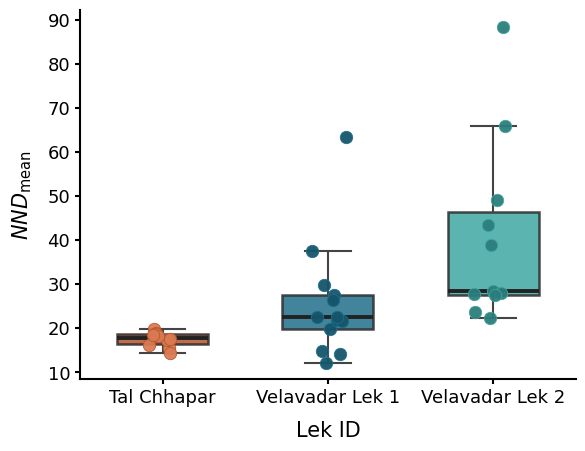

In [5]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_mean'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_mean'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{mean}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_mean.png', dpi=300, bbox_inches='tight')

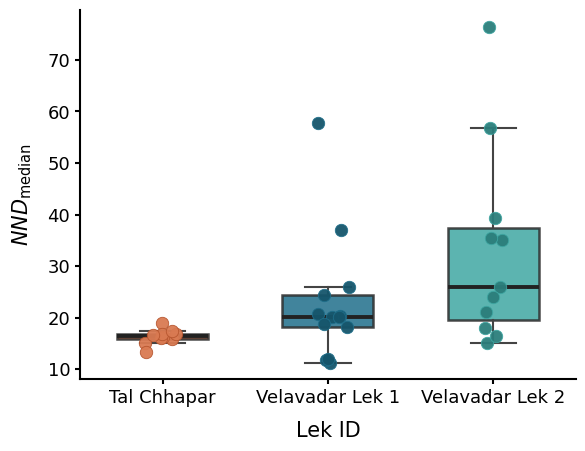

In [6]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_median'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_median'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{median}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_median.png', dpi=300, bbox_inches='tight')

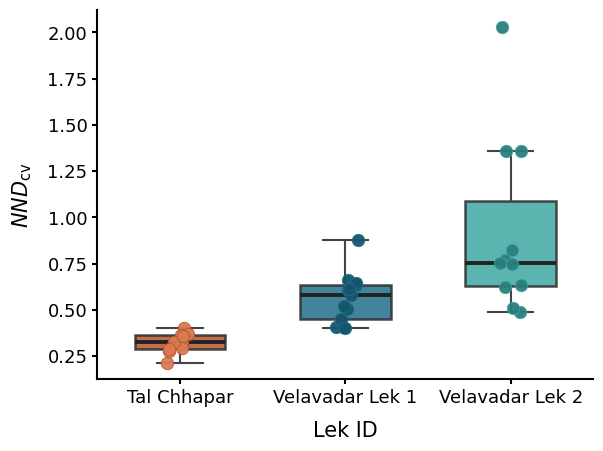

In [7]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_cv'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_cv'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{cv}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_cv.png', dpi=300, bbox_inches='tight')

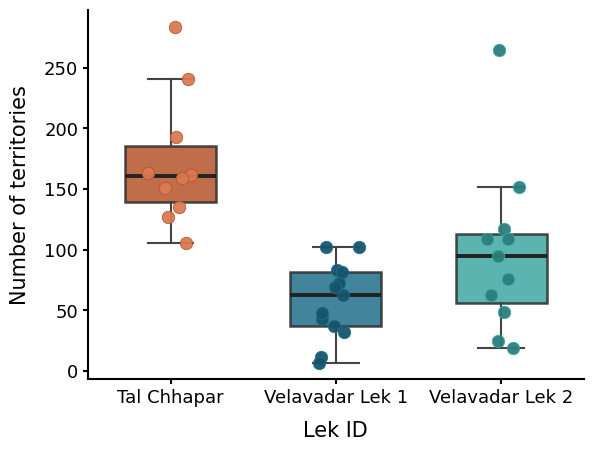

In [8]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_count'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_count'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel('Number of territories', fontsize=15, labelpad=10)


plt.savefig(out_dir/'territory_count.png', dpi=300, bbox_inches='tight')

In [9]:
df['date'] = pd.to_datetime(df['date'])

df = df[['lek_id', 'date', 'nnd_median', 'nnd_cv', 'nnd_count']].dropna().copy()
df = df.sort_values(['lek_id', 'date']).reset_index(drop=True)

## Serialise and centre the date / time
t0 = df['date'].min()
df['t_years'] = (df['date'] - t0).dt.days / 365.25
df['t_centred'] = df['t_years'] - df['t_years'].mean()

## Log transform nnd columns to construct a log-normal model
df['log_nnd_median'] = np.log(df['nnd_median'].astype(float))
df['log_nnd_cv'] = np.log(df['nnd_cv'].astype(float))
df['log_nnd_count'] = np.log(df['nnd_count'].astype(float))

## Encode lek ID in a numerical variable
lek_levels = sorted(df['lek_id'].unique())
lek_map = {lek: i + 1 for i, lek in enumerate(lek_levels)}
df['site_id'] = df['lek_id'].map(lek_map).astype(int)

In [12]:
## Model the change in median and CV of the NND to show that local repulsion interactions remain conserved
local_repulsion_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] n_territories;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;
  real gamma;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 0.5);
  gamma ~ normal(0, 0.5);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}

generated quantities {
  vector[n_points] y_hat;
  for (n in 1:n_points) {
    y_hat[n] = normal_rng(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}
"""

In [17]:
data_repulsion = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'n_territories': df['log_nnd_count'].astype(float).to_numpy(),
    'y': df['log_nnd_median'].astype(float).to_numpy()
}

posterior = stan.build(local_repulsion_mod, data=data_repulsion)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   1% (100/8000)
Sampling:   2% (200/8000)
Sampling:   4% (300/8000)
Sampling:   5% (400/8000)
Sampling:   8% (600/8000)
Sampling:  11% (900/8000)
Sampling:  15% (1200/8000)
Sampling:  19% (1500/8000)
Sampling:  22% (1800/8000)
Sampling:  26% (2100/8000)
Sampling:  29% (2300/8000)
Sampling:  34% (2700/8000)
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x751703c2ad80> is already entered
Sampling:  51% (4100/8000)
Sampling:  68% (5400/8000)
Sampling:  85% (6800/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 9.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.91 seconds.
  Adjust yo

In [18]:
fit

<stan.Fit>
Parameters:
    mu_alpha: ()
    mu_beta: ()
    gamma: ()
    alpha_raw: (3,)
    beta_raw: (3,)
    tau_alpha: ()
    tau_beta: ()
    sigma: ()
    alpha: (3,)
    beta: (3,)
    y_hat: (34,)
Draws: 4000

In [65]:
## Fix the number of territories for each lek to median to plot the effect of time on NND
fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()

## Specify time axis
t_min, t_max = float(df['t_centred'].min()), float(df['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)

/tmp/ipykernel_121685/1822275005.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()


In [86]:
t_grid.shape

(200,)

In [91]:
fit['gamma'].reshape(-1,1)

array([[-0.53630113],
       [-0.51150745],
       [-0.49687052],
       ...,
       [-0.46688425],
       [-0.4356821 ],
       [-0.52786168]], shape=(4000, 1))

In [125]:
df_lek['nnd_median']

23    56.790136
24    39.367583
25    76.476943
26    15.047014
27    34.976833
28    35.513240
29    25.955352
30    23.970444
31    17.940420
32    16.351541
33    21.025648
Name: nnd_median, dtype: float64

In [129]:
df_lek

,lek_id,date,nnd_median,nnd_cv,nnd_count,t_years,t_centred,log_nnd_median,log_nnd_cv,log_nnd_count,site_id,nnd_median_adj
23,Velavadar Lek 2,2014-02-01,56.790136,0.622051,25,1.336071,-4.236824,4.039363,-0.474733,3.218876,3,56.170418
24,Velavadar Lek 2,2015-05-01,39.367583,1.361266,76,2.579055,-2.993840,3.672943,0.308415,4.330733,3,39.263997
25,Velavadar Lek 2,2015-11-01,76.476943,0.488903,19,3.082820,-2.490075,4.336989,-0.715591,2.944439,3,75.729828
26,Velavadar Lek 2,2016-01-01,15.047014,0.769526,117,3.249829,-2.323066,2.711180,-0.261981,4.762174,3,15.143708
27,Velavadar Lek 2,2016-11-01,34.976833,0.825015,63,4.084873,-1.488022,3.554686,-0.192354,4.143135,3,34.786163
28,Velavadar Lek 2,2018-10-01,35.513240,0.633447,49,5.998631,0.425736,3.569906,-0.456579,3.891820,3,35.205908
29,Velavadar Lek 2,2018-11-01,25.955352,0.507292,109,6.083504,0.510609,3.256378,-0.678668,4.691348,3,26.019168
30,Velavadar Lek 2,2021-03-01,23.970444,0.749009,152,8.413415,2.840520,3.176822,-0.289005,5.023881,3,24.188624
31,Velavadar Lek 2,2021-12-01,17.940420,1.356874,95,9.166324,3.593429,2.887056,0.305184,4.553877,3,17.940420
32,Velavadar Lek 2,2022-12-01,16.351541,2.031269,109,10.165640,4.592745,2.794322,0.708661,4.691348,3,16.415356


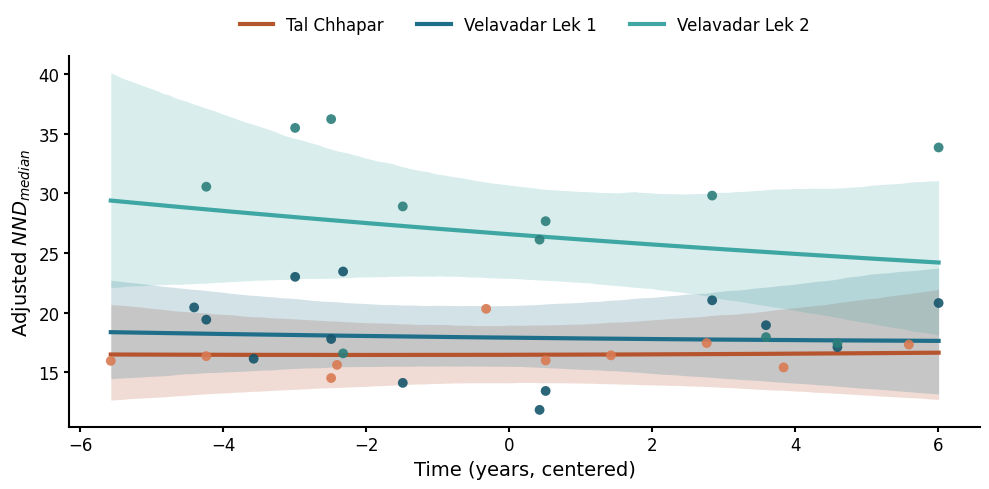

In [134]:
## Plot the change in NND with time while controlling for the number of territories
fig, ax = plt.subplots(figsize=(10, 5))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]
    logN0 = fix_logN[lek]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:] + fit['gamma'].reshape(-1,1) * logN0
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(t_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(t_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot (logNND_adjusted = logNND_observed + gamma * (logN_0 - logN_obs))
    df_lek['nnd_median_adj'] = np.exp(df_lek['log_nnd_median'] + fit['gamma'].mean() * (logN0 - df['log_nnd_count']))
    ax.scatter(df_lek['t_centred'], df_lek['nnd_median_adj'], s=50, color=point_cols.get(lek), edgecolor='none', alpha=0.9, zorder=5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Time (years, centered)', fontsize=14)
    ax.set_ylabel('Adjusted $NND_{median}$', fontsize=14)

    ax.legend(frameon=False, fontsize=12, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15))
    plt.tight_layout()